# 13. Decision Tree

## Objective
Learn how a Decision Tree makes classification decisions using Gini Impurity, then train and evaluate a Decision Tree on the Titanic dataset.

### Learning flow
1. Understand the Decision Tree concept
2. Practice Gini Impurity with a small Titanic example
3. Visualize the small Decision Tree
4. Prepare the real Titanic dataset
5. Train the Decision Tree
6. Make predictions
7. Evaluate the model using accuracy, confusion matrix, precision, recall, F1-score, and classification report

## 1. What is a Decision Tree?

A Decision Tree is a **supervised machine learning algorithm** that makes predictions by asking a sequence of questions about the input features.

It looks similar to a flowchart:

`Feature → Question/Split → Branch → Next split → Prediction`

For Titanic, the target is `Survived`:
- `0` = Not Survived
- `1` = Survived

### Why do we use it here?
Our target is categorical (`0` or `1`), so we use `DecisionTreeClassifier`. The tree can learn rules from features such as `Sex`, `Pclass`, `Age`, and `Fare`.

## 2. Gini Impurity

**Gini Impurity** measures how mixed the classes are inside a group.

- Gini = `0` → the group is completely pure (only one class).
- Higher Gini → the group contains a mixture of classes.
- For a binary classification problem, the maximum Gini is `0.5` when the two classes are evenly mixed.

Formula:

`Gini = 1 - (p0² + p1²)`

### Why do we use it here?
A Decision Tree compares possible splits and prefers splits that make the resulting groups more pure.

## 3. Small 10-Passenger Example

Before using the real Titanic dataset, we use a tiny dataset so we can see the tree's logic clearly.

We will compare possible splits using `Sex` and `Pclass`.

In [0]:
import pandas as pd

data = {
    "Sex": ["Female", "Female", "Female", "Female", "Female",
            "Male", "Male", "Male", "Male", "Male"],
    "Pclass": [1, 1, 2, 3, 3, 1, 2, 3, 1, 3],
    "Survived": [1, 1, 1, 1, 0, 0, 0, 0, 1, 0]
}

small_df = pd.DataFrame(data)
print(small_df)

      Sex  Pclass  Survived
0  Female       1         1
1  Female       1         1
2  Female       2         1
3  Female       3         1
4  Female       3         0
5    Male       1         0
6    Male       2         0
7    Male       3         0
8    Male       1         1
9    Male       3         0


### 3.1 Manual Gini Calculation

For `Sex`:
- Female: 4 survived, 1 did not survive → Gini = `0.32`
- Male: 1 survived, 4 did not survive → Gini = `0.32`
- Weighted Gini for the Sex split = `0.32`

For `Pclass`:
- Pclass 1 → Gini = `0.375`
- Pclass 2 → Gini = `0.5`
- Pclass 3 → Gini = `0.375`
- Weighted Gini for the Pclass split = `0.40`

Therefore, for this small example, the `Sex` split has the lower weighted Gini.

In [0]:
def gini_impurity(survived, not_survived):
    total = survived + not_survived
    p_survived = survived / total
    p_not_survived = not_survived / total
    gini = 1 - (p_survived**2 + p_not_survived**2)
    return gini

print(round(gini_impurity(4, 1), 2))

0.32


In [0]:
female_gini = gini_impurity(4, 1)
male_gini = gini_impurity(1, 4)

weighted_gini_sex = (5 / 10) * female_gini + (5 / 10) * male_gini

print(round(weighted_gini_sex, 2))

0.32


In [0]:
pclass1_gini = gini_impurity(3, 1)
pclass2_gini = gini_impurity(1, 1)
pclass3_gini = gini_impurity(1, 3)

weighted_gini_pclass = (4 / 10) * pclass1_gini + (2 / 10) * pclass2_gini + (4 / 10) * pclass3_gini

print(round(weighted_gini_pclass, 2))

0.4


### 3.2 Train a Tree on the Small Example

The Decision Tree performs this split-selection process internally when `.fit()` is called. We do not normally calculate every Gini value by hand; the small example is for understanding the mechanism.

`Sex` is encoded numerically because scikit-learn models require numerical feature values in this workflow.

In [0]:
X_small = small_df[["Sex", "Pclass"]].copy()
X_small["Sex"] = X_small["Sex"].map({"Female": 1, "Male": 0})
y_small = small_df["Survived"]

print(X_small)
print(y_small)

   Sex  Pclass
0    1       1
1    1       1
2    1       2
3    1       3
4    1       3
5    0       1
6    0       2
7    0       3
8    0       1
9    0       3
0    1
1    1
2    1
3    1
4    0
5    0
6    0
7    0
8    1
9    0
Name: Survived, dtype: int64


In [0]:
from sklearn.tree import DecisionTreeClassifier

tree_small = DecisionTreeClassifier(random_state=42)
tree_small.fit(X_small, y_small)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


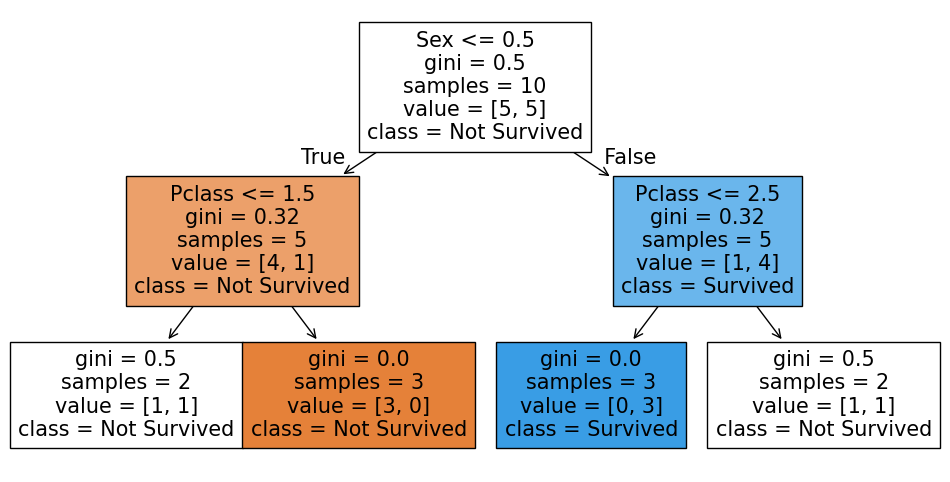

In [0]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(
    tree_small,
    feature_names=["Sex", "Pclass"],
    class_names=["Not Survived", "Survived"],
    filled=True
)
plt.show()

### How to read the tree

Each node can show:
- **feature <= threshold** → the question used to split the data
- **gini** → impurity of that node
- **samples** → number of rows reaching that node
- **value** → class counts, shown as `[class 0 count, class 1 count]`

For our encoded example, `Male = 0` and `Female = 1`. Therefore a condition such as `Sex <= 0.5` sends males to the left branch and females to the right branch.

In [0]:
y_pred_small = tree_small.predict(X_small)
print(y_pred_small)

[1 1 1 0 0 0 0 0 0 0]


In [0]:
from sklearn.metrics import accuracy_score

small_accuracy = accuracy_score(y_small, y_pred_small)
print(small_accuracy)

0.8


The small example produced **80% accuracy** on the 10 practice rows. This example is for learning the mechanics of a tree; the real model must be evaluated on unseen test data.

## 4. Decision Tree on the Real Titanic Dataset

Now we move from the 10-row learning example to the prepared Titanic dataset stored in the Databricks Delta table `default.titanic_encoded`.

### Why do we use this table?
The table contains the features after our earlier feature engineering and categorical encoding work, so the data is ready for model training.

In [0]:
df = spark.table("default.titanic_encoded").toPandas()
print(df.shape)

(891, 38)


In [0]:
X = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "Survived"])
y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 33)
(891,)


### Why create X and y?

- `X` contains the **input features** used by the model.
- `y` contains the **target** the model is trying to predict.

We remove identifiers/raw text columns that are not being used directly as model features. `Survived` is removed from `X` because it is the answer we want the model to learn to predict.

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 33)
(179, 33)
(712,)
(179,)


### Why train/test split?

We use **80% of the data for training** and **20% for testing**.

- Training data → the tree learns patterns.
- Test data → evaluates performance on unseen rows.

`random_state=42` makes the split reproducible.

In [0]:
tree_model = DecisionTreeClassifier(random_state=42)

### Why `DecisionTreeClassifier`?

`Survived` contains classes `0` and `1`, so this is a classification problem. The model will learn decision rules from the training features.

In [0]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### What does `.fit()` do?

`.fit(X_train, y_train)` trains the model. The tree examines the training data, evaluates possible splits using impurity, and builds a tree of decision rules.

In [0]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:10])
print(y_test[:10])

[0 1 0 1 1 1 1 0 1 1]
709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64


### Why predict using `X_test`?

The model should make predictions using only the test features. We then compare those predictions with `y_test`, which contains the actual answers.

Always keep these paired:

`X_test → model.predict() → y_pred_tree`

then compare `y_pred_tree` with `y_test`.

## 5. Model Evaluation

We now evaluate the Decision Tree on the 179 unseen test passengers.

In [0]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)
print(tree_accuracy)

0.8044692737430168


### Accuracy

Accuracy is the proportion of all test predictions that were correct.

For this run, the Decision Tree accuracy is approximately **80.45%**.

In [0]:
from sklearn.metrics import confusion_matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)

[[88 17]
 [18 56]]


### Confusion Matrix

For binary classification, the matrix is interpreted as:

`[[TN, FP], [FN, TP]]`

For this run:
- TN = 88
- FP = 17
- FN = 18
- TP = 56

The four values add up to 179 test passengers.

In [0]:
from sklearn.metrics import precision_score

tree_precision = precision_score(y_test, y_pred_tree)
print(tree_precision)

0.7671232876712328


### Precision

Precision asks: **Of the passengers predicted as survived, how many actually survived?**

`Precision = TP / (TP + FP)`

For this run, precision is approximately **76.71%**.

In [0]:
from sklearn.metrics import recall_score

tree_recall = recall_score(y_test, y_pred_tree)
print(tree_recall)

0.7567567567567568


### Recall

Recall asks: **Of all passengers who actually survived, how many did the model identify?**

`Recall = TP / (TP + FN)`

For this run, recall is approximately **75.68%**.

In [0]:
from sklearn.metrics import f1_score

tree_f1 = f1_score(y_test, y_pred_tree)
print(tree_f1)

0.7619047619047619


### F1-score

F1-score combines precision and recall into one metric.

For this run, the F1-score is approximately **76.19%**.

In [0]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       105
           1       0.77      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



## 6. Classification Report Interpretation

The classification report summarizes precision, recall, F1-score, and support for each class.

For the current test split:
- Class 0 support = 105
- Class 1 support = 74
- Overall accuracy = about 80%

For Class 1 (`Survived`), precision is about 77%, recall about 76%, and F1-score about 76%.

## 7. Logistic Regression vs Decision Tree

Both models were evaluated using the same Titanic test split. The observed results are:

| Metric | Logistic Regression | Decision Tree |
|---|---:|---:|
| Accuracy | 82.68% | 80.45% |
| Precision | 78.67% | 76.71% |
| Recall | 79.73% | 75.68% |
| F1-score | 79.19% | 76.19% |

This table records the results from this particular train/test split; model performance can change with different data, preprocessing, or hyperparameters.

## 8. Key Takeaways

- A Decision Tree learns a sequence of feature-based rules.
- Gini Impurity measures how mixed the classes are in a node.
- Lower Gini means a purer node.
- `.fit()` trains the tree.
- `.predict()` generates predictions for new rows.
- Test predictions must be compared with the matching `y_test` values.
- Accuracy, precision, recall, F1-score, and the confusion matrix describe different aspects of classification performance.
- The small 10-passenger example helped us understand what the real Decision Tree is doing internally.